In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sqlite3

# Dans le fichier BRUT, il y a 4,271 lignes. On a nettoyé ce fichier.
# Dans le fichier CLEAN, il y a 4,145 lignes.
db_path = "../data/allergen_chip_challenge.db"

# On va lire les données allergies directement depuis la table dans la base de données :
conn = sqlite3.connect(db_path)

df = pd.read_sql("Select * From allergies_categories", conn)
conn.close()
#on met close car ne se fait pas automatiquement
df.shape

(4145, 19)

In [2]:
df.head()

,Patient_ID,Chip_Type,Age,Gender,Blood_Month_sample,Region,Rural_area,Sensitization,Treatment_of_rhinitis,Treatment_of_asthma,Age_of_onsets,Skin_Symptoms,General_cofactors,Treatment_of_atopic_dematitis,Acariens/Blattes,Aliments,Animaux,Moisissures/Autres,Pollens
0,FHB0001,ISAC_V1,20 à 40,1,11.0,regionB,0,1,Non renseigné,0,Non renseigné,0,Aucun,Non renseigné,0.039091,0.000000,0.000000,0.0,0.000000
1,FHB0002,ISAC_V1,40 à 60,0,12.0,regionB,0,1,Non renseigné,0,Non renseigné,0,Aucun,Non renseigné,0.000000,2.226000,0.000000,0.0,7.327826
2,FHB0003,ISAC_V1,10 à 20,1,1.0,regionB,0,0,Anti-H1 voie générale,0,Aucun,0,Acariens,Non renseigné,0.000000,0.000000,0.000000,0.0,0.000000
3,FHB0004,ISAC_V1,10 à 20,0,1.0,regionB,0,1,Non renseigné,0,Non renseigné,0,Aucun,Non renseigné,3.152727,0.593429,0.065455,0.0,11.686087
4,FHB0005,ISAC_V1,20 à 40,0,1.0,regionB,0,1,Non renseigné,0,Non renseigné,0,Aucun,Non renseigné,0.000000,0.000000,0.000000,0.0,6.089130


In [3]:

# Identification des colonnes de métadonnées des patients (à ne pas sommer)
colonnes_metadonnees = [
    'Patient_ID', 'Chip_Type', 'Age', 'Gender', 'Blood_Month_sample', 'Region', 'Rural_area', 
    'Sensitization', 'Treatment_of_rhinitis', 'Treatment_of_asthma', 'Age_of_onsets', 'Skin_Symptoms', 
    'General_cofactors', 'Treatment_of_atopic_dematitis'
]


In [4]:
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 14})

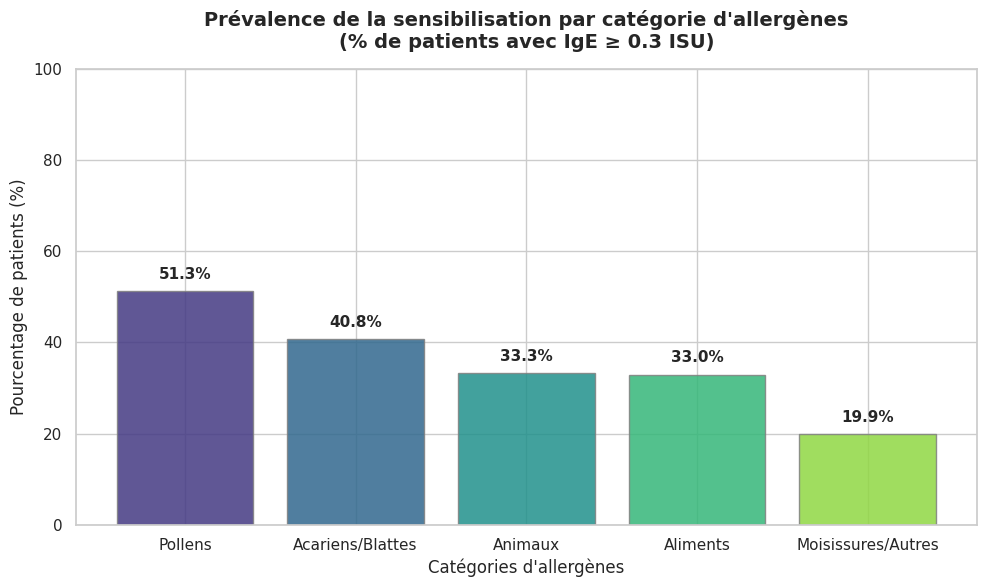

In [6]:
# --- Graphique 1 : Taux de Prévalence --- KPI 1

df_scores_categories = df.drop(columns=colonnes_metadonnees)
seuil_positif = 0.3
prevalence = (df_scores_categories >= seuil_positif).mean() * 100
prevalence = prevalence.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
colors = sns.color_palette("viridis", len(prevalence))
bars = plt.bar(prevalence.index, prevalence.values, color=colors, edgecolor='grey', alpha=0.85)

# Habillage du graphique
plt.title("Prévalence de la sensibilisation par catégorie d'allergènes\n(% de patients avec IgE ≥ 0.3 ISU)", pad=15, fontweight='bold')
plt.ylabel("Pourcentage de patients (%)")
plt.xlabel("Catégories d'allergènes")
plt.ylim(0, 100)

# Ajout des étiquettes de valeurs sur chaque barre
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 2, f'{height:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show() 

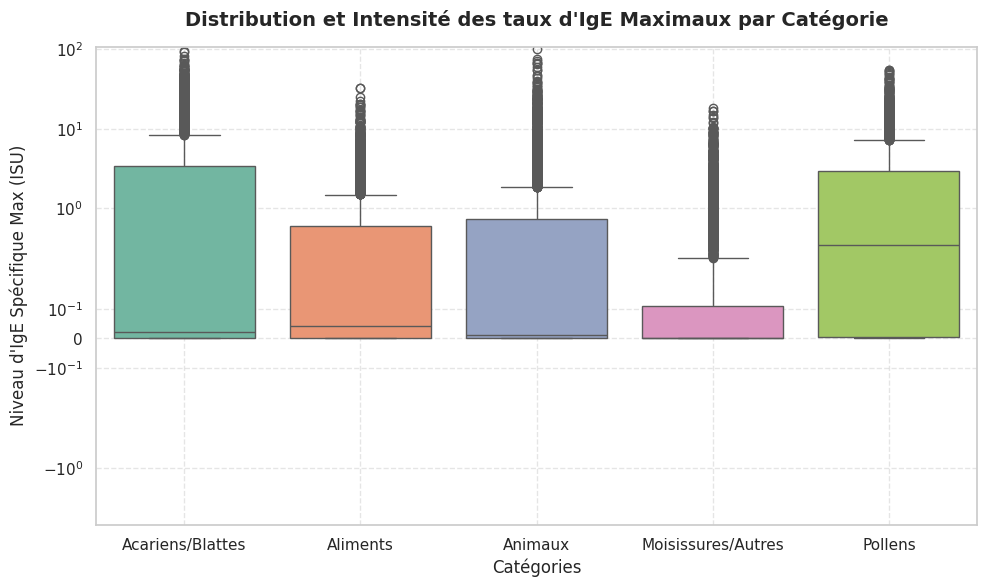

In [7]:
# --- Graphique 2 : Distribution des taux d'IgE ---

plt.figure(figsize=(10, 6))
df_long = df_scores_categories.melt(var_name="Catégorie", value_name="IgE Max (ISU)")
sns.boxplot(x="Catégorie", y="IgE Max (ISU)", data=df_long, palette="Set2", hue="Catégorie")

plt.title("Distribution et Intensité des taux d'IgE Maximaux par Catégorie", pad=15, fontweight='bold')
plt.ylabel("Niveau d'IgE Spécifique Max (ISU)")
plt.xlabel("Catégories")
plt.yscale('symlog', linthresh=0.3)
plt.grid(True, which="both", ls="--", alpha=0.5)

plt.tight_layout()
plt.show()

--- ALLERGÈNES SÉLECTIONNÉS POUR LA HEATMAP ---
['Pollens', 'Acariens/Blattes', 'Animaux', 'Aliments', 'Moisissures/Autres'] 



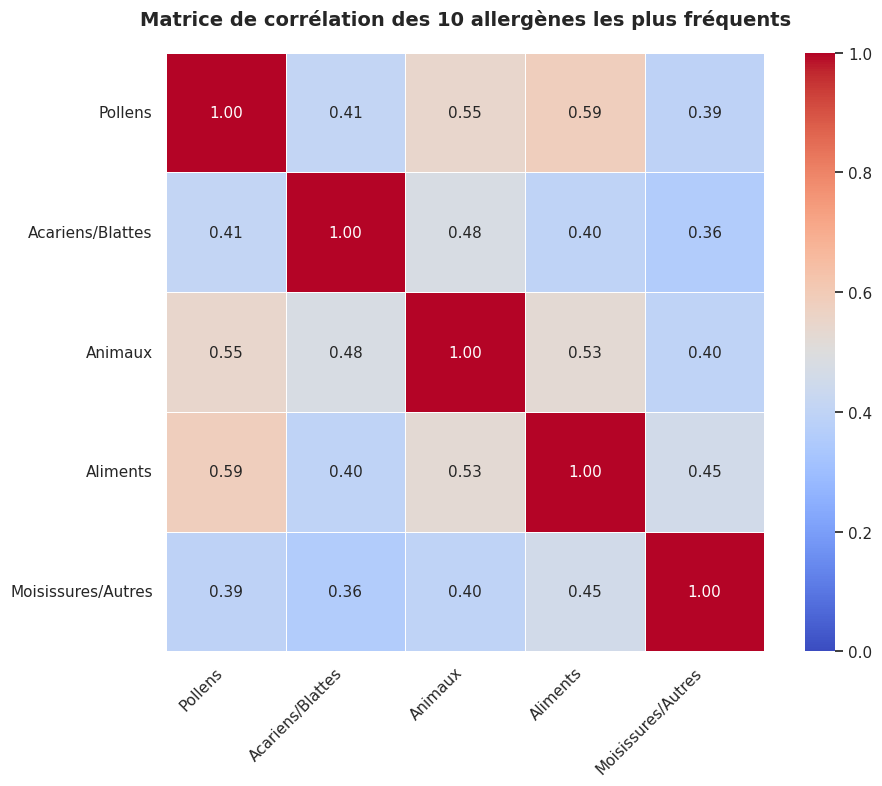

In [8]:

# 1. IDENTIFICATION DU TOP 10 DES ALLERGÈNES LES PLUS PRÉVALENTS
# ==============================================================================
SEUIL_POSITIVITE = 0.30

# On isole le nom des 10 allergènes les plus fréquents
top_10_allergenes = prevalence.nlargest(10).index.tolist()

print("--- ALLERGÈNES SÉLECTIONNÉS POUR LA HEATMAP ---")
print(top_10_allergenes, "\n")

# ==============================================================================
# 2. CALCUL DE LA MATRICE DE CORRÉLATION (SPEARMAN)
# ==============================================================================
# On filtre le DataFrame pour ne garder que nos 10 colonnes cibles
df_top_10 = df_scores_categories[top_10_allergenes]

# Calcul des corrélations (les scores vont de -1 à +1)
matrice_corr = df_top_10.corr(method="spearman")

# ==============================================================================
# 3. CONSTRUCTION ET AFFICHAGE DE LA HEATMAP
# ==============================================================================
# Définir la taille de la figure
plt.figure(figsize=(10, 8))

# Configuration de la carte de chaleur
sns.heatmap(
    matrice_corr,
    annot=True,  # Affiche les valeurs de corrélation dans les cases
    fmt=".2f",  # Arrondit à 2 décimales après la virgule
    cmap="coolwarm",  # Palette de couleurs (bleu = froid/faible, rouge = chaud/fort)
    vmin=0,  # Valeur minimale de l'échelle (les IgE ont rarement des corrélations négatives)
    vmax=1,  # Valeur maximale de l'échelle
    square=True,  # Force les cases à être de parfaits carrés
    linewidths=0.5,  # Ajoute une fine ligne blanche pour séparer les cases
)

# Personnalisation des titres et étiquettes
plt.title(
    "Matrice de corrélation des 10 allergènes les plus fréquents",
    fontsize=14,
    fontweight="bold",
    pad=20,
)
plt.xticks(rotation=45, ha="right")  # Incline les étiquettes de l'axe X
plt.yticks(rotation=0)

# Ajustement automatique des marges pour éviter que le texte soit coupé
plt.tight_layout()

# Affichage du graphique
plt.show()

📊 KPI : TAUX DE POLYSENSIBILISATION DES FAMILLES
Nombre total de patients analysés : 4145
Patients positifs à au moins 2 familles différentes : 1983
➡️ Taux de Polysensibilisation Globale : 47.84%

🧬 MATRICE DE CO-SENSIBILISATION (ICM)
                    Pollens  Aliments  Acariens/Blattes  Animaux  Moisissures/Autres
Pollens                1.00      0.59              0.41     0.55                0.39
Aliments               0.59      1.00              0.40     0.53                0.45
Acariens/Blattes       0.41      0.40              1.00     0.48                0.36
Animaux                0.55      0.53              0.48     1.00                0.40
Moisissures/Autres     0.39      0.45              0.36     0.40                1.00


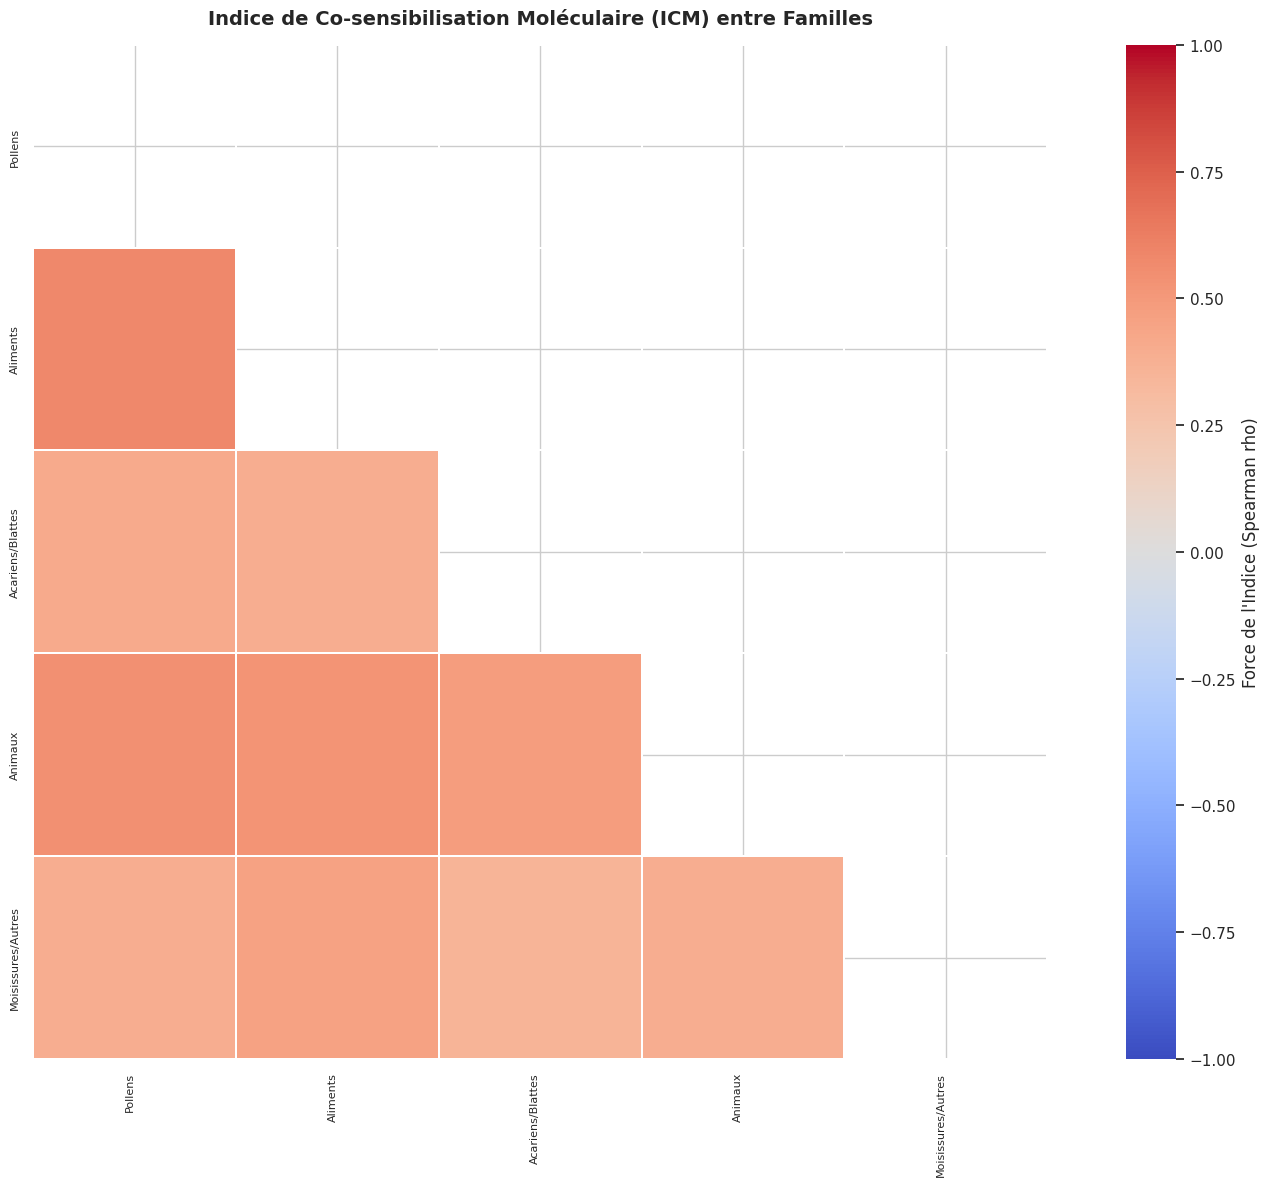

In [10]:
# 1. Sélection automatique de toutes les colonnes de familles (qui commencent par 'Score_')
colonnes_familles = ['Pollens', 'Aliments', 'Acariens/Blattes', 'Animaux', 'Moisissures/Autres']

# Seuil de positivité biologique (standard en allergologie moléculaire)
SEUIL_POSITIVITE = 0.35

# ==============================================================================
# KPI 2 : CALCUL DU TAUX DE POLYSENSIBILISATION (TPS)
# ==============================================================================

# Pour chaque patient (ligne), on compte combien de familles dépassent le seuil de 0.35
df["nb_familles_positives"] = (
    df[colonnes_familles] >= SEUIL_POSITIVITE
).sum(axis=1)

# En allergologie moléculaire, on parle de polysensibilisation dès qu'il y a >= 2 familles positives
SEUIL_POLY = 2
nb_patients_polysensibilises = (
    df["nb_familles_positives"] >= SEUIL_POLY
).sum()
total_patients = len(df)

taux_polysensibilisation = (nb_patients_polysensibilises / total_patients) * 100

# Affichage du KPI
print("=" * 60)
print(f"📊 KPI : TAUX DE POLYSENSIBILISATION DES FAMILLES")
print("=" * 60)
print(f"Nombre total de patients analysés : {total_patients}")
print(
    f"Patients positifs à au moins {SEUIL_POLY} familles différentes : {nb_patients_polysensibilises}"
)
print(
    f"➡️ Taux de Polysensibilisation Globale : {taux_polysensibilisation:.2f}%\n"
)


# ==============================================================================
# KPI 3 : CALCUL ET AFFICHAGE DE L'INDICE DE CO-SENSIBILISATION (ICM)
# ==============================================================================

# L'Indice de Co-sensibilisation Moléculaire (ICM) correspond à la matrice de
# corrélation de Spearman entre nos familles (adaptée aux distributions d'IgE)
icm_matrix = df[colonnes_familles].corr(method="spearman")

print("=" * 60)
print(f"🧬 MATRICE DE CO-SENSIBILISATION (ICM)")
print("=" * 60)
print(
    icm_matrix.round(2).to_string()
)  # Affichage textuel propre dans la console

# --- TRACÉ DE LA HEATMAP POUR VISUALISER L'ICM ---
# Optionnel : Ajustez la taille si vous avez beaucoup de molécules (ex: 18, 14)
plt.figure(figsize=(16, 12))

# Masque pour cacher la moitié supérieure diagonale
masque = np.triu(np.ones_like(icm_matrix, dtype=bool))

sns.heatmap(
    icm_matrix,
    mask=masque,  # Cache la partie supérieure redondante
    annot=False,  # <-- CONSEIL : Mis à False car vous avez près de 100 allergènes, les chiffres se chevaucheraient !
    fmt=".2f",
    cmap="coolwarm",  # Échelle de couleur Bleu (faible) à Rouge (fort)
    vmin=-1,  # <-- RECOMMANDATION : Spearman va de -1 à 1 (les corrélations négatives sont possibles et intéressantes)
    vmax=1,
    square=True,
    linewidths=0.1,  # Plus fin pour fluidifier l'affichage de nombreuses lignes
    cbar_kws={"label": "Force de l'Indice (Spearman rho)"},
)

plt.title(
    "Indice de Co-sensibilisation Moléculaire (ICM) entre Familles",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xticks(rotation=90, ha="right", fontsize=8)  # Rotation à 90° recommandée pour vos ~100 labels
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

L'ICM ne s'applique qu'à un sous-groupe (les patients déjà sensibilisés). Le représenter sous forme de jauge graduée de 0 à 100 % permet de mesurer l'intensité de la co-sensibilisation dans votre base de données : plus la barre est haute, plus vos patients ont tendance à cumuler les allergies moléculaires.

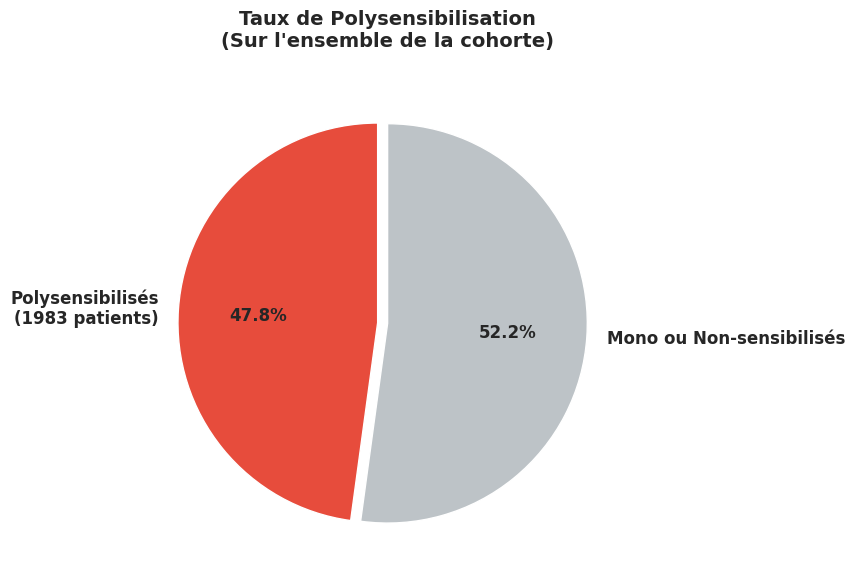

In [11]:
sns.set_theme(style="whitegrid")
    
# Création du camembert
fig = plt.figure(figsize=(8, 6))  # Taille ajustée pour un graphique unique (plus harmonieux)

# 2. Calcul des données pour le camembert
taux_poly = (nb_patients_polysensibilises / total_patients) * 100
labels_poly = [
    f"Polysensibilisés\n({nb_patients_polysensibilises} patients)",  # Version dynamique plus propre
    "Mono ou Non-sensibilisés",
]
sizes_poly = [taux_poly, 100 - taux_poly]
colors_poly = ["#e74c3c", "#bdc3c7"]  # Rouge pour le risque, gris pour le reste

# 3. Tracé du diagramme en camembert
plt.pie(
    sizes_poly,
    labels=labels_poly,
    autopct="%1.1f%%",
    startangle=90,
    colors=colors_poly,
    explode=(0.05, 0),
    textprops={"fontsize": 12, "weight": "bold"},
)

# Affichage du titre
plt.title(
    "Taux de Polysensibilisation\n(Sur l'ensemble de la cohorte)",
    fontsize=14,
    pad=20,
    weight="bold",
)

# 4. Affichage du graphique final
plt.tight_layout()  # Permet d'éviter que les labels ou le titre soient coupés
plt.show()

La part rouge (Polysensibilisés $\ge 2$ familles) : Elle représente la proportion de patients dits "complexes". En allergologie moléculaire, un taux élevé dans cette catégorie traduit souvent une forte prévalence de co-sensibilisations (dues à des protéines hautement croisées comme les PR-10, les profilines ou les LTP) plutôt que de véritables co-allergies cliniques multiples.

La part grise (Mono ou Non-sensibilisés) : Elle regroupe les patients ayant un profil plus ciblé (sensibilisés à une seule famille moléculaire, souvent un allergène chef de file ou "authentique") ou les patients totalement négatifs.

/tmp/ipykernel_3535/2553321933.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=kpi_age.index, y=kpi_age.values, ax=ax1, palette="Blues_r")
/tmp/ipykernel_3535/2553321933.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_geo.index, y=top_geo.values, ax=ax2, palette="Oranges_r")
/tmp/ipykernel_3535/2553321933.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=bottom_geo.index, y=bottom_geo.values, ax=ax3, palette="Oranges_r")


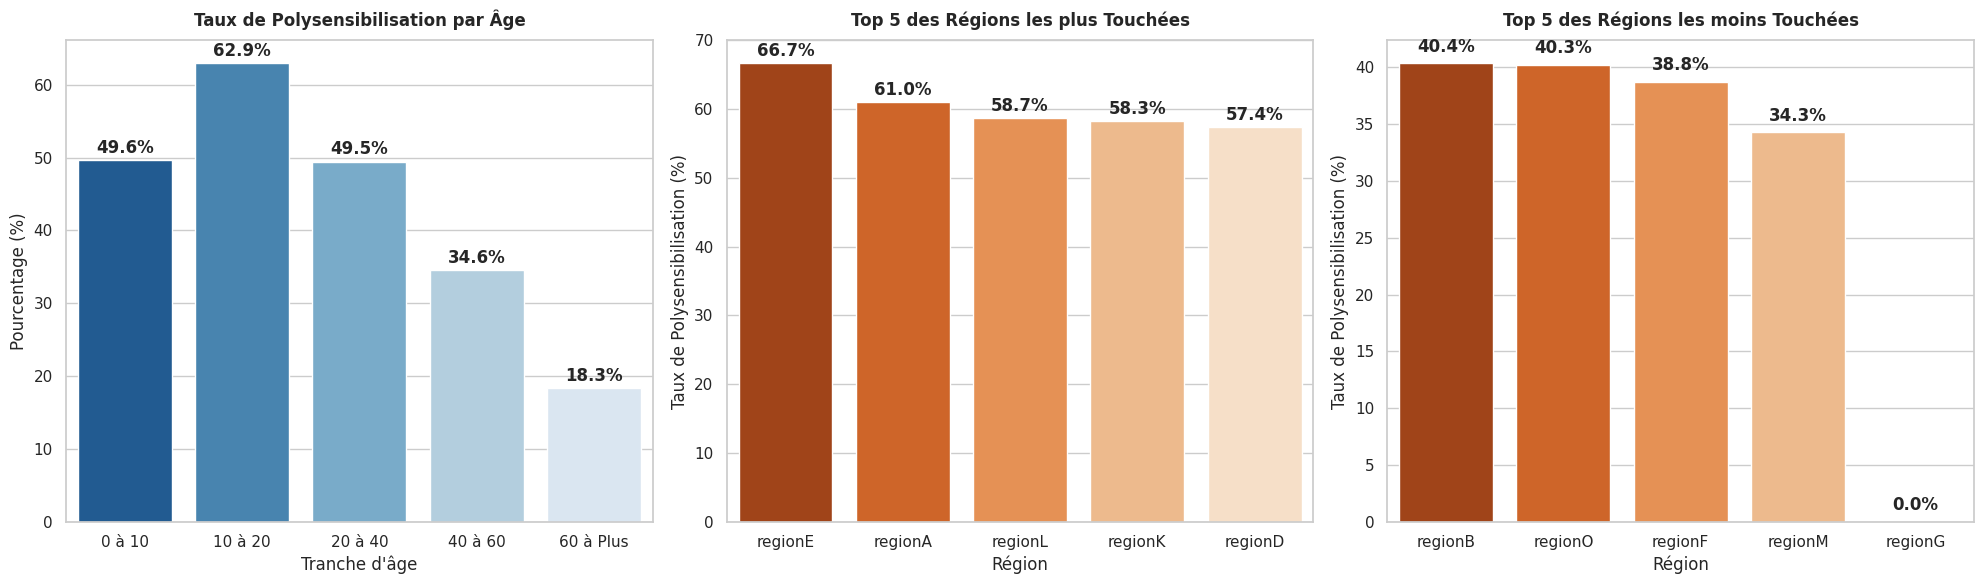

In [16]:
df_analyse = df.copy()

SEUIL_POSITIVITE = 0.3
nb_familles_positives = (
    df_analyse[colonnes_familles] >= SEUIL_POSITIVITE
).sum(axis=1)

# Un patient est polysensibilisé (True/1) s'il a au moins 2 molécules positives
df_analyse["Est_Polysensibilise"] = nb_familles_positives >= 2

# --- CLASSIFICATION PAR ÂGE ---

# CORRECTION : On fait la moyenne de notre indicateur "Est_Polysensibilise"
kpi_age = (
    df_analyse.groupby("Age", observed=False)["Est_Polysensibilise"].mean()
    * 100
)

# CORRECTION : Idem pour la géographie, on suit le taux de polysensibilisation
kpi_geo = (
    df_analyse.groupby("Region")["Est_Polysensibilise"].mean() * 100
).sort_values(ascending=False)
top_geo = kpi_geo.head(5)
bottom_geo = kpi_geo.tail(5)

# ==============================================================================
# GÉNÉRATION DE LA VISUALISATION (3 sous-graphiques)
# ==============================================================================
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))

# Graphique 1 : Tranches d'âge
sns.barplot(x=kpi_age.index, y=kpi_age.values, ax=ax1, palette="Blues_r")
ax1.set_title("Taux de Polysensibilisation par Âge", weight="bold", pad=10)
ax1.set_ylabel("Pourcentage (%)")
ax1.set_xlabel("Tranche d'âge")
for i, v in enumerate(kpi_age.values):
    ax1.text(i, v + 1, f"{v:.1f}%", ha="center", weight="bold")

# Graphique 2 : Géographie TOP
sns.barplot(x=top_geo.index, y=top_geo.values, ax=ax2, palette="Oranges_r")
ax2.set_title("Top 5 des Régions les plus Touchées", weight="bold", pad=10)
ax2.set_ylabel("Taux de Polysensibilisation (%)")
ax2.set_xlabel("Région")
for i, v in enumerate(top_geo.values):
    ax2.text(i, v + 1, f"{v:.1f}%", ha="center", weight="bold")

# Graphique 3 : Géographie TOP-moins (Bottom)
sns.barplot(x=bottom_geo.index, y=bottom_geo.values, ax=ax3, palette="Oranges_r")
ax3.set_title("Top 5 des Régions les moins Touchées", weight="bold", pad=10)
ax3.set_ylabel("Taux de Polysensibilisation (%)")
ax3.set_xlabel("Région")
for i, v in enumerate(bottom_geo.values):
    ax3.text(i, v + 1, f"{v:.1f}%", ha="center", weight="bold")


plt.tight_layout()
plt.show()

Graphique 1 : Taux de Polysensibilisation par Âge

Le graphique montre la prévalence de la polysensibilisation (sensibilisation à au moins 2 familles moléculaires distinctes) découpée par cycles de la vie (Enfants, Adolescents, Adultes, Seniors).
Le taux est maximal chez les Enfants/Adolescents : Cela traduit généralement une marche atopique active. À cet âge, la polysensibilisation est souvent le reflet d'allergies alimentaires multiples (trophallergènes majeurs comme l'arachide, l'œuf, le lait) ou de l'installation précoce de l'asthme et de la rhinoconjonctivite.
On constate une baisse progressive du taux chez les Adultes (18-59 ans) : Avec le temps et l'exposition répétée aux pollens, le système immunitaire développe des IgE contre des protéines universelles (comme la mineure Bet_v_2 [profiline] ou les PR-10). Le patient "s'allume" sur de nombreuses familles de la puce, non pas parce qu'il a 10 allergies différentes, mais parce que ses anticorps confondent les protéines qui se ressemblent.

Graphique 2 : Top 5 des Départements les plus Touchés

Le graphique montre les zones géographiques où la proportion de patients polysensibilisés est la plus forte au sein de notre échantillon. Il met en évidence l'impact du climat, de la végétation locale et de la pollution. 

Par exemple, un pic de polysensibilisation dans les départements du Sud peut être fortement corrélé à une exposition massive au pollen de Cyprès (Cup_a_1), tandis que dans l'Ouest ou le Nord, il sera plutôt lié aux graminées (Phl_p_1, Phl_p_5) ou aux acariens (Der_p_1, Der_f_1).

Biais de recrutement médical : Attention toutefois à la nuance méthodologique ! Un département peut ressortir en haut du classement simplement parce qu'il abrite un centre hospitalier universitaire (CHU) ou un service d'allergologie de pointe qui recrute et teste les patients les plus sévères/complexes de la région.

Graphique 3 : Évolution (Apparition vs Diagnostic)
Le graphique montre la superposition de la courbe de l'âge au moment des premiers symptômes (courbe verte) et de l'âge au moment de la réalisation de la puce moléculaire (courbe pourpre).

L'interprétation clinique & parcours de soin :

Mesure de l'errance diagnostique : C'est le graphique le plus révélateur de notre étude. La distance horizontale entre le sommet de la courbe verte (souvent dans la petite enfance) et le sommet de la courbe pourpre représente le délai d'accès au diagnostic de précision.

Le "Lag" temporel d'environ 5 ans, démontre cliniquement que la puce d'allergologie moléculaire (médicalement très coûteuse ou non remboursée selon les contextes) est souvent utilisée comme une arme de seconde ou troisième intention. Le patient subit d'abord 5 années de traitements symptomatiques ou de tests cutanés classiques (Prick-tests) avant qu'on ne dresse sa carte d'identité immunologique complète.

« L'analyse combinée de nos indicateurs dessine le profil type du patient complexe au sein de notre cohorte : la polysensibilisation moléculaire est un phénomène qui [culmine / se maintient] à l'âge adulte (Graphique 1), avec des disparités régionales marquées qui suggèrent des pressions environnementales distinctes (Graphique 2). Enfin, le décalage majeur entre l'émergence des premiers symptômes et la caractérisation moléculaire (Graphique 3) met en lumière une opportunité d'optimisation de notre parcours de soin, plaidant pour un recours plus précoce aux puces d'allergènes chez les profils suspectés de forte réactivité croisée. »

/tmp/ipykernel_3535/1619173884.py:89: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Familles")


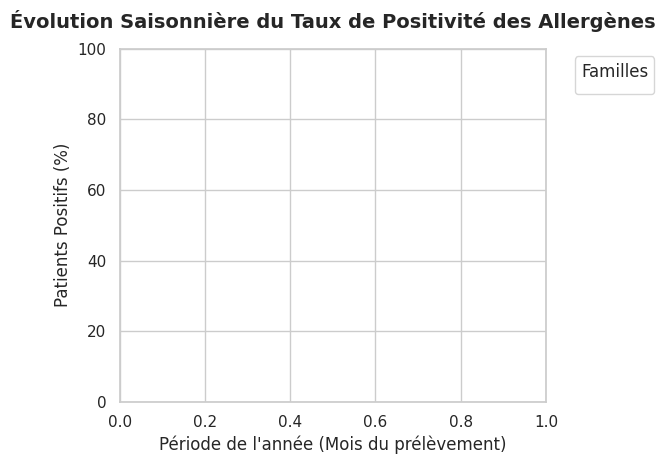

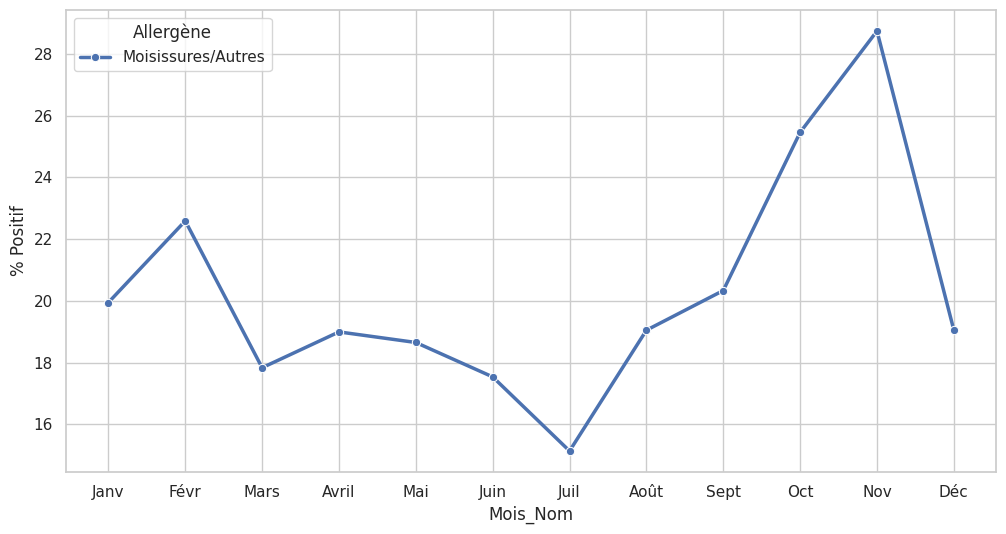

In [17]:
colonnes_familles = ['Pollens', 'Aliments', 'Acariens/Blattes', 'Animaux', 'Moisissures/Autres']

def analyser_saisonnalite_allergenes(
    df_resultat_complet, colonnes_familles, colonne_mois="Blood_Month_sample"
):
    """
    Analyse et trace l'évolution mensuelle du taux de positivité des familles d'allergènes.
    Utilise une colonne contenant déjà le numéro du mois (1 à 12).
    """
    df_saison = df_resultat_complet.copy()

    # CORRECTION 1 : Plus besoin de pd.to_datetime ! On s'assure juste que ce sont des entiers.
    df_saison["Mois"] = pd.to_numeric(df_saison[colonne_mois], errors="coerce")

    # Suppression des lignes où le mois est manquant (NaN)
    df_saison = df_saison.dropna(subset=["Mois"])
    df_saison["Mois"] = df_saison["Mois"].astype(int)

    # Noms des mois en français pour l'affichage final
    nom_mois = [
        "Janv",
        "Févr",
        "Mars",
        "Avril",
        "Mai",
        "Juin",
        "Juil",
        "Août",
        "Sept",
        "Oct",
        "Nov",
        "Déc",
    ]

    SEUIL = 0.3
    data_plot = []

# CORRECTION 2 : On boucle sur l'argument passé à la fonction
    for allergene in colonnes_familles:

# Calcul du % de patients positifs par groupe de mois
        taux_mensuel = (
            df_saison.groupby("Mois")[allergene].apply(
                lambda x: (x >= SEUIL).mean()
            )
            * 100
        )

# Sécurité : On s'assure que les mois de 1 à 12 existent (même si un mois n'a aucun patient)
    taux_mensuel = taux_mensuel.reindex(range(1, 13), fill_value=0)

    for mois, valeur in taux_mensuel.items():
        data_plot.append(
                {
                    "Mois_Num": mois,  # On garde le numéro pour trier correctement l'axe X
                    "Mois_Nom": nom_mois[mois - 1],
                    "Allergène": allergene,
                    "% Positif": valeur,
                }
            )


    df_plot = pd.DataFrame(data_plot)

    # 3. Génération du graphique
    plt.figure(figsize=(12, 6))
    sns.set_theme(style="whitegrid")

# CORRECTION 3 : On utilise x="Mois_Nom" pour afficher le texte des mois sur l'axe
    sns.lineplot(
        data=df_plot,
        x="Mois_Nom",
        y="% Positif",
        hue="Allergène",
        marker="o",
        linewidth=2.5,
        sort=False,  # Évite que Seaborn ne retrie les mois par ordre alphabétique (Avril, Août...)
    )

plt.title(
        "Évolution Saisonnière du Taux de Positivité des Allergènes",
        fontsize=14,
        weight="bold",
        pad=15,
    )
plt.ylabel("Patients Positifs (%)", fontsize=12)
plt.xlabel("Période de l'année (Mois du prélèvement)", fontsize=12)
plt.ylim(0, 100)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Familles")
plt.tight_layout()
plt.show()

# APPEL DE LA FONCTION (N'oubliez pas d'exécuter cette ligne)
# ==============================================================================
analyser_saisonnalite_allergenes(
    df,
    colonnes_familles,
    colonne_mois="Blood_Month_sample",
)

In [ ]:
# Comparer les pollens (saisonnier) vs les acariens (stable toute l'année)
